## 1. Project Objective

The primary objective of this project is to **analyze the spread and impact of COVID-19 over time and build a time-series forecasting model to predict future COVID-19 trends**.

Using historical COVID-19 data, we will:

- Understand the structure and characteristics of the dataset.
- Analyze global COVID-19 trends over time.
- Study confirmed cases, deaths, recoveries, and active cases.
- Compare COVID-19 trends across countries and WHO regions.
- Identify countries and regions significantly affected by the pandemic.
- Analyze how COVID-19 cases and deaths evolved over time.
- Prepare the data for time-series forecasting.
- Build a **Prophet forecasting model** to predict future COVID-19 trends.

Therefore, this project combines **Exploratory Data Analysis, geographical analysis, time-series analysis, and forecasting**.

---

## 2. Understanding the Dataset

The dataset contains COVID-19 records collected across different countries, regions, provinces, and dates.

The major columns in the dataset are:

| Column | Description |
|-----------|-------------|
| **Province/State** | Province or state associated with the observation, where available. |
| **Country/Region** | Country or region where the COVID-19 cases were recorded. |
| **Lat** | Latitude of the geographical location. |
| **Long** | Longitude of the geographical location. |
| **Date** | Date on which the COVID-19 statistics were recorded. |
| **Confirmed** | Total number of confirmed COVID-19 cases reported up to that date. |
| **Deaths** | Total number of reported COVID-19 deaths up to that date. |
| **Recovered** | Total number of reported recovered COVID-19 cases up to that date. |
| **Active** | Number of currently active COVID-19 cases. |
| **WHO Region** | WHO geographical region to which the country belongs. |

> **Note:** The `Province/State` column contains missing values for locations where province or state-level information is not available. These missing values do not necessarily indicate missing COVID-19 observations and will be analyzed before deciding how to handle them.

---

## 3. Understanding Each Group of Features

### A. Geographical Information

The dataset contains geographical information through the following columns:

- `Country/Region`
- `Lat`
- `Long`

These columns help us understand **where COVID-19 cases were reported**.

Using this information, we can answer questions such as:

- Which countries recorded the highest number of confirmed cases?
- Which countries recorded the highest number of deaths?
- How did the pandemic evolve across different countries?
- Which geographical regions were most affected?

The latitude and longitude values provide the geographical coordinates associated with the reported location.

---

### B. Province/State

The `Province/State` column provides more detailed geographical information when it is available.

For example, a country may have observations for multiple provinces or states.

However, this column contains missing values for many observations because province-level information is not available for every country.

Therefore, the missing values in this column will first be analyzed to understand their pattern before deciding whether any preprocessing is required.

---

### C. Date

The `Date` column represents the **date on which the COVID-19 statistics were recorded**.

This is one of the most important columns in the project because COVID-19 is a **time-dependent phenomenon**.

The date allows us to analyze how COVID-19 changed over time.

For example:

**Date → Confirmed Cases**

can help us understand whether confirmed cases were:

- Increasing
- Decreasing
- Remaining relatively stable
- Experiencing significant spikes

The `Date` column will therefore be converted into an appropriate **datetime format** and will form the basis of our time-series analysis and forecasting.

---

### D. Confirmed

The `Confirmed` column represents the **total number of reported confirmed COVID-19 cases** for a particular location up to a particular date.

For example:

- `Confirmed = 1,000` → 1,000 confirmed cases had been reported.
- `Confirmed = 50,000` → 50,000 confirmed cases had been reported.

This variable will be one of the primary metrics used to understand the spread of COVID-19.

---

### E. Deaths

The `Deaths` column represents the **total number of reported COVID-19 deaths** associated with a particular observation.

This allows us to analyze the impact of the pandemic in terms of reported fatalities.

We can investigate questions such as:

- How did global deaths change over time?
- Which countries recorded the highest number of deaths?
- How did deaths compare with confirmed cases?
- How did the death trend evolve throughout the pandemic?

---

### F. Recovered

The `Recovered` column represents the **reported number of COVID-19 cases that had recovered**.

This allows us to study the recovery trend alongside confirmed cases and deaths.

By analyzing confirmed, recovered, and death figures together, we can develop a broader understanding of the progression of the pandemic.

---

### G. Active

The `Active` column represents the **number of active COVID-19 cases** at a particular point in time.

Active cases provide an indication of the current reported case burden after accounting for cases that have been classified as recovered or deceased.

This variable can help us understand periods when the number of ongoing cases was particularly high.

---

### H. WHO Region

The `WHO Region` column identifies the **World Health Organization geographical region** associated with each country.

Examples include:

- Europe
- Africa
- Americas
- Eastern Mediterranean
- South-East Asia
- Western Pacific

This allows us to compare COVID-19 trends across larger geographical regions rather than analyzing only individual countries.

---

## 4. What We Will Analyze

The project will focus on several important analytical questions.

### Global Trend Analysis

We will analyze:

- How confirmed COVID-19 cases changed over time.
- How deaths changed over time.
- How recoveries changed over time.
- How active cases changed over time.

This will help us understand the **overall progression of the COVID-19 pandemic**.

### Country-Level Analysis

We will identify:

- Countries with the highest confirmed cases.
- Countries with the highest deaths.
- Countries with the highest recovered cases.
- Countries with the highest active cases.

This will allow us to compare the impact of COVID-19 across different countries.

### Regional Analysis

Using the `WHO Region` column, we will compare different regions to understand:

- Which regions experienced the highest number of confirmed cases.
- Which regions experienced the highest number of deaths.
- How COVID-19 trends differed across regions.

---

## 5. Why Time-Series Forecasting?

COVID-19 data is inherently **time-dependent**.

The number of cases and deaths observed on a particular date is related to the trends and patterns observed during previous dates.

Therefore, instead of only analyzing historical data, we can also use historical patterns to estimate **future COVID-19 trends**.

The basic forecasting process will be:

**Historical COVID-19 Data → Identify Time Patterns → Train Forecasting Model → Forecast Future Values**

This introduces the forecasting component of the project.

---

## 6. Forecasting Using Prophet

For the forecasting stage, we will use the **Prophet model**.

Prophet is a time-series forecasting model designed to work with data containing trends, seasonality, and changing patterns over time.

For our project, the COVID-19 data will be converted into the format required by Prophet:

| ds | y |
|-----------|-----------|
| Date | Confirmed Cases |
| Date | Confirmed Cases |
| Date | Confirmed Cases |

Here:

- `ds` → Date
- `y` → Variable that we want to forecast

The model will learn patterns from historical COVID-19 data and use those patterns to generate forecasts for future dates.

Depending on the objective of the analysis, forecasting can be performed for important metrics such as **Confirmed Cases** or **Deaths**.

> **Important:** The forecast represents an estimate based on historical patterns and should not be interpreted as a guaranteed prediction of actual future COVID-19 cases or deaths.

---

## 7. Overall Problem Statement

> **Can we use historical COVID-19 data to analyze the global spread and impact of the pandemic, identify important trends across countries and regions, and use time-series forecasting to estimate future COVID-19 trends?**

The overall workflow of the project will therefore be:

**Dataset Understanding → Data Preparation → Exploratory Data Analysis → Global Trend Analysis → Country-Level Analysis → Regional Analysis → Time-Series Preparation → Prophet Model → Forecasting → Forecast Visualization & Interpretation**

The final objective is to transform raw COVID-19 records into **meaningful insights about the pandemic and a data-driven forecast of future COVID-19 trends**.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Covid_19_Clean_Complete (2).csv")
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [3]:
#Exploratory Data Analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [5]:
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Date'] = pd.to_datetime(df['Date'], errors = 'coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [9]:
df = df.drop(columns = ['Province/State'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  int64         
 5   Deaths          49068 non-null  int64         
 6   Recovered       49068 non-null  int64         
 7   Active          49068 non-null  int64         
 8   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 3.4+ MB


In [10]:
df = df.rename(columns = {'Country/Region':'Country'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Country     49068 non-null  object        
 1   Lat         49068 non-null  float64       
 2   Long        49068 non-null  float64       
 3   Date        49068 non-null  datetime64[ns]
 4   Confirmed   49068 non-null  int64         
 5   Deaths      49068 non-null  int64         
 6   Recovered   49068 non-null  int64         
 7   Active      49068 non-null  int64         
 8   WHO Region  49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 3.4+ MB


In [11]:
df = df.sort_values('Date').reset_index(drop = True)
df

,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Netherlands,18.042500,-63.054800,2020-01-22,0,0,0,0,Europe
2,Netherlands,52.132600,5.291300,2020-01-22,0,0,0,0,Europe
3,New Zealand,-40.900600,174.886000,2020-01-22,0,0,0,0,Western Pacific
4,Nicaragua,12.865416,-85.207229,2020-01-22,0,0,0,0,Americas
...,...,...,...,...,...,...,...,...,...
49063,Denmark,56.263900,9.501800,2020-07-27,13547,613,12417,517,Europe
49064,Djibouti,11.825100,42.590300,2020-07-27,5059,58,4977,24,Eastern Mediterranean
49065,Dominican Republic,18.735700,-70.162700,2020-07-27,64156,1083,30204,32869,Americas
49066,Egypt,26.820553,30.802498,2020-07-27,92482,4652,34838,52992,Eastern Mediterranean


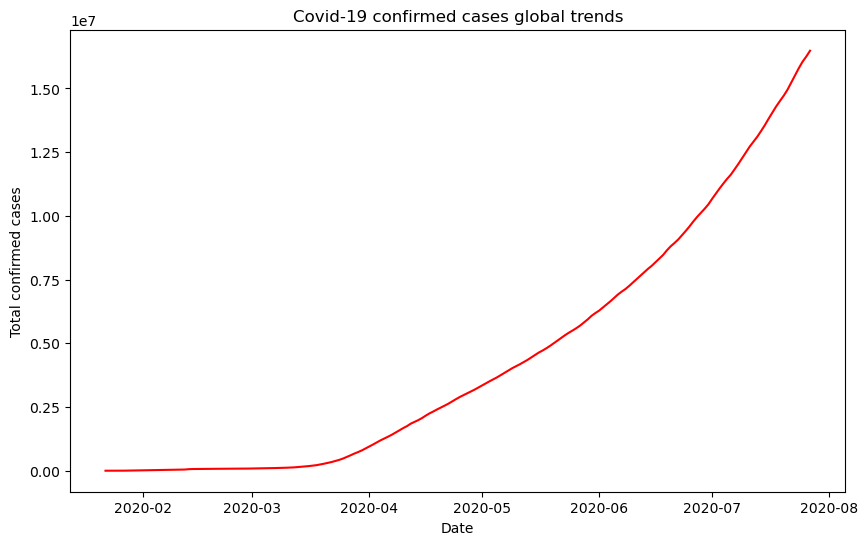

In [15]:
#How did the total number of confirmed covid-19 cases change over time globally ?
plt.figure(figsize = (10,6))
global_sum = df.groupby('Date',as_index = False)['Confirmed'].sum()
plt.plot(global_sum["Date"],
    global_sum["Confirmed"],color = 'red')
plt.xlabel("Date")
plt.ylabel("Total confirmed cases")
plt.title("Covid-19 confirmed cases global trends")
plt.show()

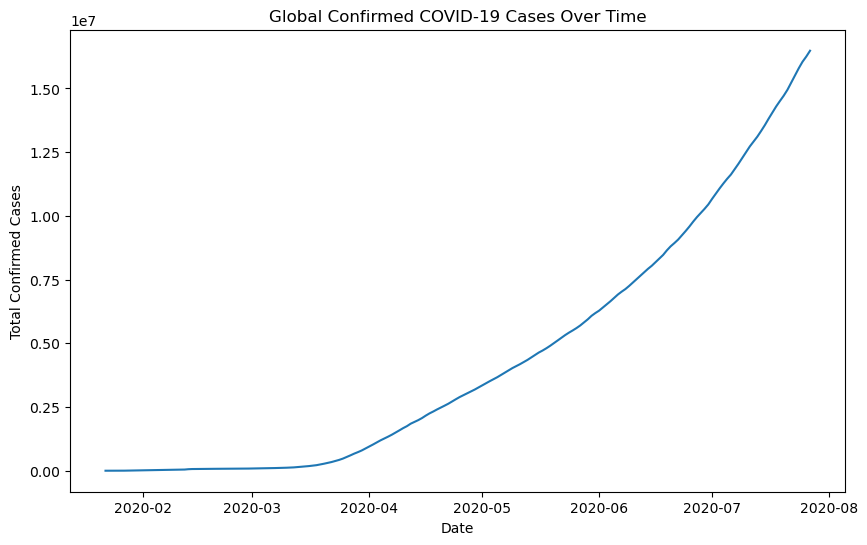

In [18]:
global_confirmed = df.groupby("Date", as_index=False)["Confirmed"].sum()
plt.figure(figsize = (10,6))
plt.plot(
    global_confirmed["Date"],
    global_confirmed["Confirmed"])
plt.title("Global Confirmed COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Confirmed Cases")
plt.show()

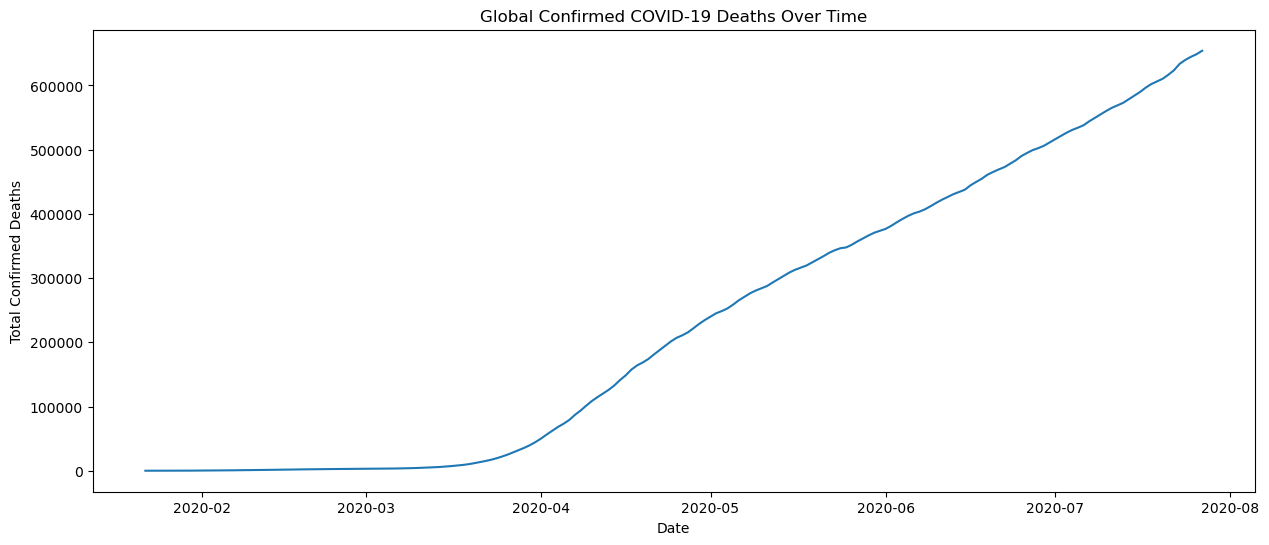

In [20]:
#Number of deaths as well as number of active cases
death_cases = df.groupby('Date',as_index = False)['Deaths'].sum()
plt.figure(figsize = (15,6))
plt.plot(
    death_cases["Date"],
    death_cases["Deaths"])
plt.title("Global Confirmed COVID-19 Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Total Confirmed Deaths")
plt.show()

In [29]:
#Which 3 countries were most affected by Covid-19
most_affected = df.groupby('Country',as_index = False)[['Confirmed','Active','Deaths','Recovered']].sum()
top3_conf = most_affected.sort_values(by = 'Confirmed',ascending = False).head(3)
top3_death = most_affected.sort_values(by = 'Deaths',ascending = False).head(3)
top3_active = most_affected.sort_values(by = 'Active',ascending = False).head(3)
top3_recovered = most_affected.sort_values(by = 'Recovered',ascending = False).head(3)

In [30]:
top3_conf

,Country,Confirmed,Active,Deaths,Recovered
173,US,224345948,156981121,11011411,56353416
23,Brazil,89524967,31094060,3938034,54492873
138,Russia,45408411,19668578,619385,25120448


In [31]:
top3_death

,Country,Confirmed,Active,Deaths,Recovered
173,US,224345948,156981121,11011411,56353416
177,United Kingdom,26748587,22624595,3997775,126217
23,Brazil,89524967,31094060,3938034,54492873


In [32]:
top3_active

,Country,Confirmed,Active,Deaths,Recovered
173,US,224345948,156981121,11011411,56353416
23,Brazil,89524967,31094060,3938034,54492873
177,United Kingdom,26748587,22624595,3997775,126217


In [33]:
top3_recovered

,Country,Confirmed,Active,Deaths,Recovered
173,US,224345948,156981121,11011411,56353416
23,Brazil,89524967,31094060,3938034,54492873
138,Russia,45408411,19668578,619385,25120448


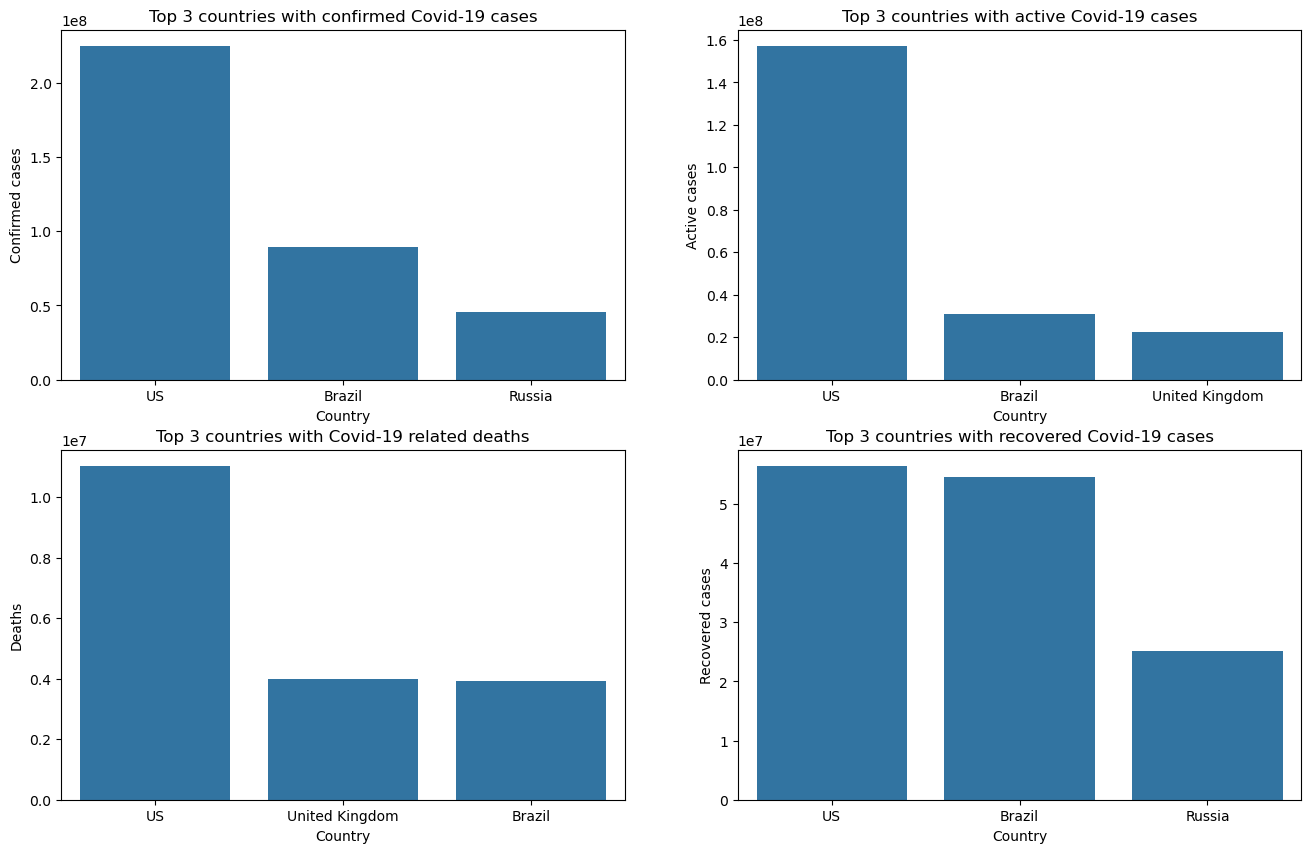

In [37]:
#How do the top 3 countries compare in terms of confirmed, death, active and recovered cases
plt.figure(figsize = (16,10))
plt.subplot(2,2,1)
sns.barplot(data = top3_conf,x='Country',y='Confirmed')
plt.title("Top 3 countries with confirmed Covid-19 cases")
plt.xlabel("Country")
plt.ylabel("Confirmed cases")
# plt.xticks(rotation = 45)

plt.subplot(2,2,2)
sns.barplot(data = top3_active,x='Country',y='Active')
plt.title("Top 3 countries with active Covid-19 cases")
plt.xlabel("Country")
plt.ylabel("Active cases")
# plt.xticks(rotation = 45)

plt.subplot(2,2,3)
sns.barplot(data = top3_death,x='Country',y='Deaths')
plt.title("Top 3 countries with Covid-19 related deaths")
plt.xlabel("Country")
plt.ylabel("Deaths")
# plt.xticks(rotation = 45)

plt.subplot(2,2,4)
sns.barplot(data = top3_recovered,x='Country',y='Recovered')
plt.title("Top 3 countries with recovered Covid-19 cases")
plt.xlabel("Country")
plt.ylabel("Recovered cases")
# plt.xticks(rotation = 45)
plt.show()

In [40]:
from prophet import Prophet
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

In [41]:
confirmed_cases = df.groupby('Date')['Confirmed'].sum().reset_index()
prophet_data = confirmed_cases.rename(columns = {'Date':'ds','Confirmed':'y'})
prophet_data = prophet_data.sort_values('ds').reset_index(drop = True)
prophet_data

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [43]:
train, test = train_test_split(prophet_data,test_size = 0.2,shuffle = False)
model = Prophet()
model.fit(train)
forecast = model.predict(test[['ds']])
actual = test['y'].values
predicted = forecast['yhat'].values

12:29:09 - cmdstanpy - INFO - Chain [1] start processing
12:29:10 - cmdstanpy - INFO - Chain [1] done processing


In [44]:
mae = mean_absolute_error(actual,predicted)
rmse = np.sqrt(mean_squared_error(actual,predicted))
print("MAE",mae)
print("RMSE",rmse)

MAE 1510442.2401881344
RMSE 1811725.9660910536


In [45]:
res = pd.DataFrame({
    'Date':test['ds'],
    'Actual':actual,
    'Predicted':predicted
})
res

,Date,Actual,Predicted
150,2020-06-20,8805336,8.618788e+06
151,2020-06-21,8933875,8.735327e+06
152,2020-06-22,9071733,8.848277e+06
153,2020-06-23,9237071,8.967111e+06
154,2020-06-24,9408254,9.088591e+06
155,2020-06-25,9586141,9.212845e+06
156,2020-06-26,9777487,9.337835e+06
157,2020-06-27,9955597,9.452564e+06
158,2020-06-28,10117227,9.569103e+06
159,2020-06-29,10275799,9.682053e+06


In [46]:
future = model.make_future_dataframe(periods = 7)
final_forecast = model.predict(future)
print(final_forecast[['ds','yhat_lower','yhat_upper','yhat']].tail(7))

            ds    yhat_lower    yhat_upper          yhat
150 2020-06-20  8.580519e+06  8.651462e+06  8.618788e+06
151 2020-06-21  8.702452e+06  8.774152e+06  8.735327e+06
152 2020-06-22  8.811786e+06  8.883111e+06  8.848277e+06
153 2020-06-23  8.931864e+06  9.004956e+06  8.967111e+06
154 2020-06-24  9.047467e+06  9.127412e+06  9.088591e+06
155 2020-06-25  9.170593e+06  9.252886e+06  9.212845e+06
156 2020-06-26  9.289192e+06  9.385613e+06  9.337835e+06


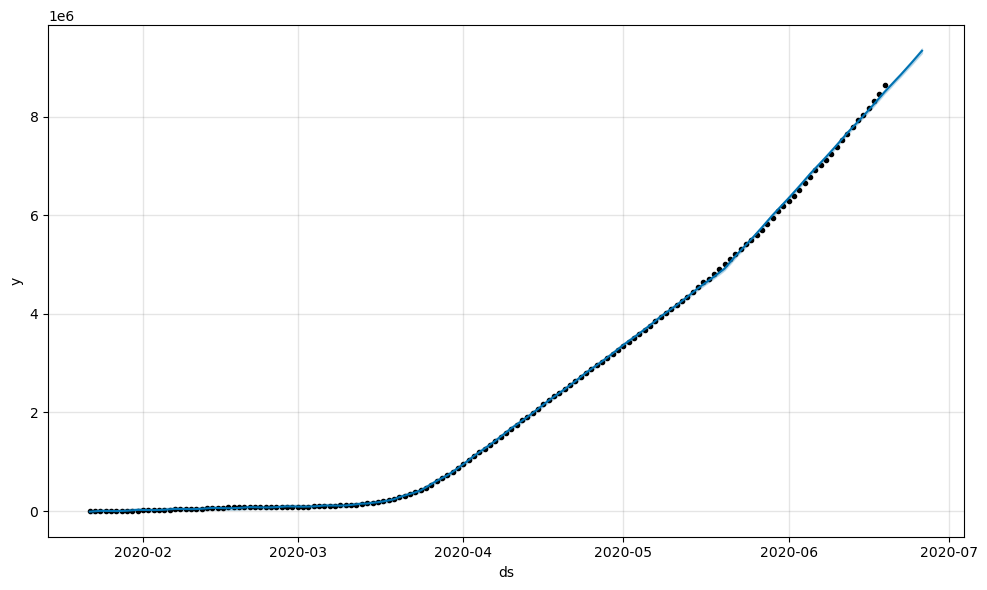

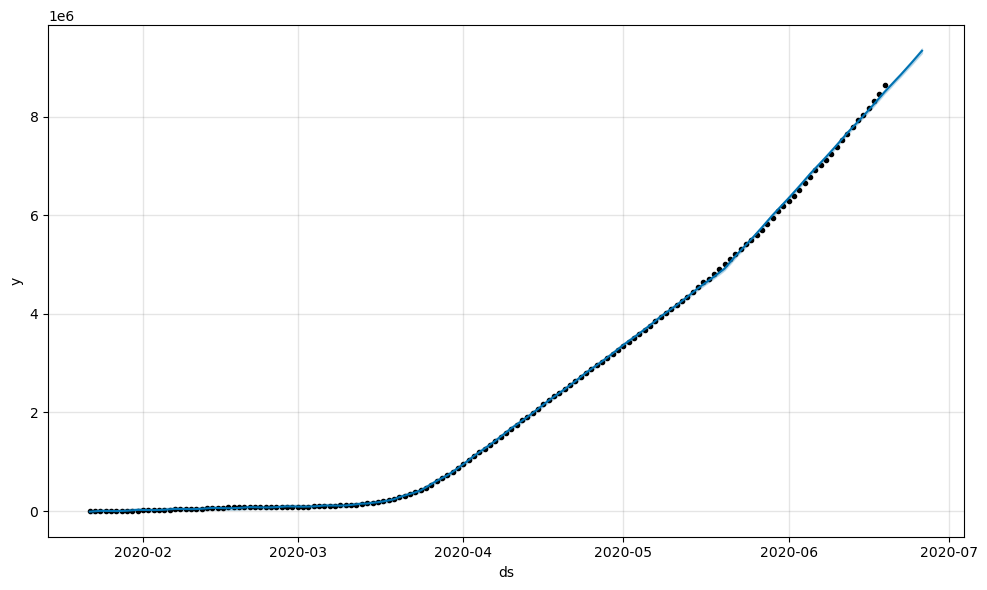

In [47]:
model.plot(final_forecast)